In [2]:
import os

os.listdir("../data")

['product_info.csv',
 'reviews_0-250.csv',
 'reviews_1250-end.csv',
 'reviews_250-500.csv',
 'reviews_500-750.csv',
 'reviews_750-1250.csv']

In [3]:
import pandas as pd
import glob

reviews = pd.concat([pd.read_csv(f) for f in glob.glob("../data/reviews_*.csv")], ignore_index=True)

products = pd.read_csv("../data/product_info.csv")

C:\Users\andre\AppData\Local\Temp\ipykernel_7720\3469066939.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat([pd.read_csv(f) for f in glob.glob("../data/reviews_*.csv")], ignore_index=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_7720\3469066939.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat([pd.read_csv(f) for f in glob.glob("../data/reviews_*.csv")], ignore_index=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_7720\3469066939.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.concat([pd.read_csv(f) for f in glob.glob("../data/reviews_*.csv")], ignore_index=True)


In [4]:
reviews.shape

(1094411, 19)

In [5]:
products.shape

(8494, 27)

# Phase 1 - Exploration et visualisation des données

In [8]:
print("=== REVIEWS ===")
print(reviews.columns.tolist())

print("\n=== PRODUCTS ===")
print(products.columns.tolist())

=== REVIEWS ===
['Unnamed: 0', 'author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd']

=== PRODUCTS ===
['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count', 'rating', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']


## On explore les premières lignes et les valeurs manquantes :

In [9]:
# Aperçu des données
print("=== REVIEWS ===")
print(reviews.head(3))

print("\n=== PRODUCTS ===")
print(products.head(3))

# Valeurs manquantes
print("\n=== VALEURS MANQUANTES REVIEWS ===")
print(reviews.isnull().sum())

print("\n=== VALEURS MANQUANTES PRODUCTS ===")
print(products.isnull().sum())

=== REVIEWS ===
   Unnamed: 0    author_id  rating  is_recommended  helpfulness  \
0           0   1741593524       5             1.0          1.0   
1           1  31423088263       1             0.0          NaN   
2           2   5061282401       5             1.0          NaN   

   total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
0                     2                         0                         2   
1                     0                         0                         0   
2                     0                         0                         0   

  submission_time                                        review_text  \
0      2023-02-01  I use this with the Nudestix “Citrus Clean Bal...   
1      2023-03-21  I bought this lip mask after reading the revie...   
2      2023-03-21  My review title says it all! I get so excited ...   

                       review_title skin_tone eye_color skin_type hair_color  \
0  Taught me how to double cl

## Visualisation de la distribution des notes 


In [11]:
import os
os.makedirs('../plots', exist_ok=True)

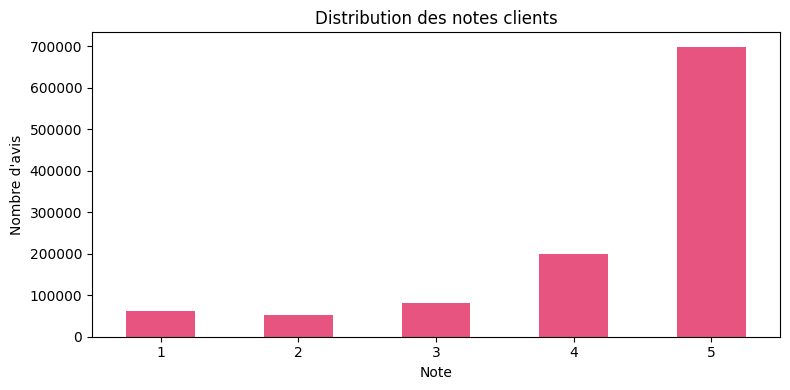

rating
1     61223
2     53032
3     81816
4    199389
5    698951
Name: count, dtype: int64


In [12]:
import matplotlib.pyplot as plt

# Distribution des notes dans reviews
plt.figure(figsize=(8, 4))
reviews['rating'].value_counts().sort_index().plot(kind='bar', color='#e75480')
plt.title('Distribution des notes clients')
plt.xlabel('Note')
plt.ylabel('Nombre d\'avis')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../plots/distribution_notes.png')
plt.show()

print(reviews['rating'].value_counts().sort_index())

64% des avis sont des 5 étoiles (698 951) — les clients Sephora sont globalement très satisfaits
Les notes 1, 2, 3 sont minoritaires
Notre seuil ≥ 4 pour good_rating est bien justifié — ça représente environ 83% des avis (notes 4 + 5)

## Exploration des catégories de produits :

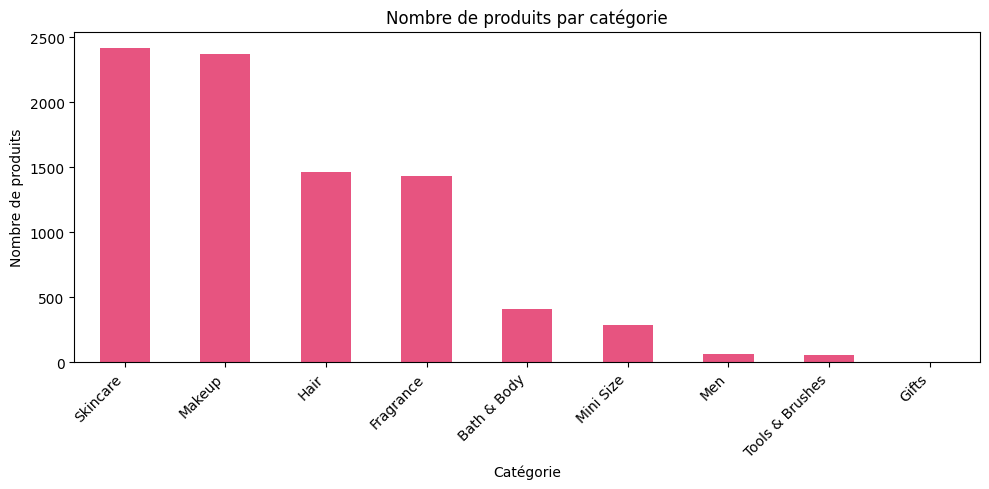

primary_category
Skincare           2420
Makeup             2369
Hair               1464
Fragrance          1432
Bath & Body         405
Mini Size           288
Men                  60
Tools & Brushes      52
Gifts                 4
Name: count, dtype: int64


In [13]:
# Distribution par catégorie
plt.figure(figsize=(10, 5))
products['primary_category'].value_counts().plot(kind='bar', color='#e75480')
plt.title('Nombre de produits par catégorie')
plt.xlabel('Catégorie')
plt.ylabel('Nombre de produits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../plots/categories.png')
plt.show()

print(products['primary_category'].value_counts())

Skincare et Makeup dominent — 57% du catalogue
Hair et Fragrance sont bien représentés
Les catégories Gifts, Tools & Brushes et Men sont très minoritaires

## Distribution des prix 

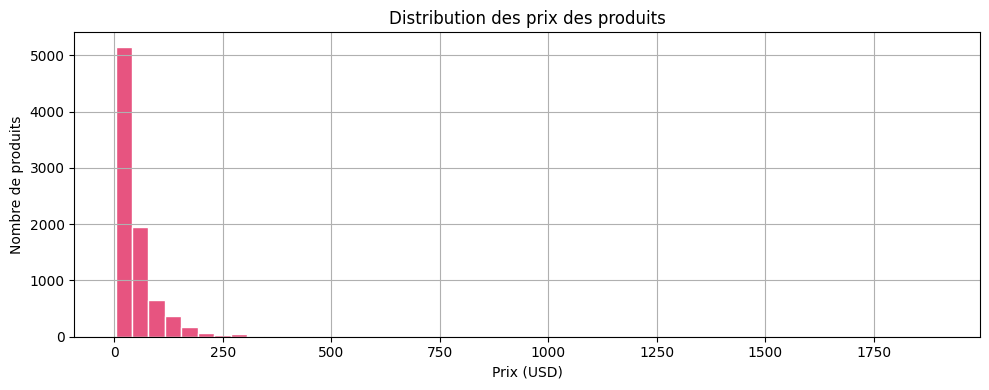

count    8494.000000
mean       51.655595
std        53.669234
min         3.000000
25%        25.000000
50%        35.000000
75%        58.000000
max      1900.000000
Name: price_usd, dtype: float64


In [14]:
plt.figure(figsize=(10, 4))
products['price_usd'].hist(bins=50, color='#e75480', edgecolor='white')
plt.title('Distribution des prix des produits')
plt.xlabel('Prix (USD)')
plt.ylabel('Nombre de produits')
plt.tight_layout()
plt.savefig('../plots/distribution_prix.png')
plt.show()

print(products['price_usd'].describe())

Prix médian : 35$, prix moyen : 52$ — la majorité des produits sont accessibles
Quelques outliers très chers (jusqu'à 1900$) — on les gardera mais c'est à noter
Distribution très asymétrique à droite, classique en e-commerce

# Phase 2 — nettoyage et création de la variable cible.

In [15]:
# 1. Fusionner les deux datasets sur product_id
df = reviews.merge(products, on='product_id', suffixes=('_review', '_product'))

# 2. Supprimer les colonnes inutiles
cols_to_drop = [
    'Unnamed: 0', 'author_id', 'helpfulness', 'review_text', 'review_title',
    'submission_time', 'eye_color', 'hair_color', 'skin_tone',
    'value_price_usd', 'sale_price_usd', 'variation_desc',
    'brand_id', 'variation_type', 'variation_value',
    'child_count', 'child_max_price', 'child_min_price',
    'product_name_review', 'product_name_product', 'brand_name_review'
]
df = df.drop(columns=cols_to_drop)

# 3. Créer la variable cible
df['good_rating'] = (df['rating_review'] >= 4).astype(int)

# 4. Vérifier
print(df.shape)
print(df['good_rating'].value_counts())
print(df.isnull().sum())

(1094411, 25)
good_rating
1    898340
0    196071
Name: count, dtype: int64
rating_review                    0
is_recommended              167988
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count         0
skin_type                   111557
product_id                       0
price_usd_review                 0
brand_name_product               0
loves_count                      0
rating_product                   0
reviews                          0
size                         43363
ingredients                  22025
price_usd_product                0
limited_edition                  0
new                              0
online_only                      0
out_of_stock                     0
sephora_exclusive                0
highlights                  113936
primary_category                 0
secondary_category               0
tertiary_category           161256
good_rating                      0
dtype: int64


In [16]:
# Supprimer les lignes sans skin_type (trop de NaN pour imputer)
df = df.dropna(subset=['skin_type'])

# Remplir les manquants restants
df['size'] = df['size'].fillna('Unknown')
df['ingredients'] = df['ingredients'].fillna('Unknown')
df['highlights'] = df['highlights'].fillna('Unknown')
df['tertiary_category'] = df['tertiary_category'].fillna('Unknown')
df['is_recommended'] = df['is_recommended'].fillna(df['is_recommended'].median())

# Vérifier
print(df.shape)
print(df.isnull().sum().sum(), "valeurs manquantes restantes")

(982854, 25)
0 valeurs manquantes restantes
